# Tarea 3

Somos el equipo 5, conformados por:
  - Raúl Llamosas Alvarado
  - Eumir Rendon Uresti
  - Gabriela Peña Franco
  - Daniela Ibarra Gatica
  - Randy Jesús García Mejía
  - Daniela Vázquez Sánchez



Vamos a usar una base de datos de rentas de bicicletas por hora `Bike Sharing Demand` disponible en Scikit-learn. Tenemos datos de la forma

$$(x_t, y_t),$$

donde $x_t$ es un vector de características, $y_t$ el número de bicicletas rentadas al tiempo $t$. Aplicar el algoritmo *Online Gradient Descent* a esta base de datos y evaluar su Regret.

1. Descripción del problema
2. Metodología
3. Resultados, tablas, gráficas
4. Conclusiones

### Descripción del problema


El problema abordado en este trabajo consiste en predecir la demanda horaria de bicicletas en el sistema de alquiler compartido "Bike Sharing" de la ciudad de Washington D.C.
El objetivo es implementar el algoritmo Online Gradient Descent (OGD) para actualizar los parámetros de un modelo de regresión lineal de manera secuencial, a medida que se observan nuevos ejemplos

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error

bike_sharing = fetch_openml("Bike_Sharing_Demand", version=2, as_frame=True)
bike_sharing.frame.head(5)

,season,year,month,hour,holiday,weekday,workingday,weather,temp,feel_temp,humidity,windspeed,count
0,spring,0,1,0,False,6,False,clear,9.84,14.395,0.81,0.0,16
1,spring,0,1,1,False,6,False,clear,9.02,13.635,0.80,0.0,40
2,spring,0,1,2,False,6,False,clear,9.02,13.635,0.80,0.0,32
3,spring,0,1,3,False,6,False,clear,9.84,14.395,0.75,0.0,13
4,spring,0,1,4,False,6,False,clear,9.84,14.395,0.75,0.0,1


Vamos a separar en columnas númericas, categóricas y binarias:

In [16]:
df = bike_sharing.frame

columnas_numericas = ['temp', 'feel_temp', 'humidity', 'windspeed']
columnas_categoricas = ['year','season', 'weather', 'weekday', 'month', 'hour']
columnas_binarias = ['holiday', 'workingday']

Ahora usamos Column Transformer y corremos el pipeline:

In [17]:
preprocesador = ColumnTransformer([
    ('num', StandardScaler(), columnas_numericas),
    ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), columnas_categoricas)
])

X = df[columnas_numericas + columnas_categoricas + columnas_binarias]
y = df['count'].values

X_entrada, X_prueba, y_entrada, y_prueba = train_test_split(
    X, y, test_size=0.3, random_state=42
)

pipeline = Pipeline([
    ('preprocesador', preprocesador)
])

pipeline.fit(X_entrada)
X_entrada_proc = pipeline.transform(X_entrada)
X_prueba_proc = pipeline.transform(X_prueba)

num_caracteristicas = X_entrada_proc.shape[1]

n = len(X_entrada_proc)
w_ogd = np.zeros(num_caracteristicas)
tasa_aprendizaje = 0.01

perdidas_online = []
perdidas_acumuladas = []
regret_acumulado = []

# Calcular el mejor predictor fijo UNA SOLA VEZ con TODOS los datos
w_opt, _, _, _ = np.linalg.lstsq(X_entrada_proc, y_entrada, rcond=None)
perdida_opt_total = np.sum((np.dot(X_entrada_proc, w_opt) - y_entrada) ** 2)
perdida_opt_acumulada = 0

for t in range(n):
    x_t = X_entrada_proc[t]
    y_t = y_entrada[t]
    
    pred_t = np.dot(w_ogd, x_t)
    
    error_t = pred_t - y_t
    perdida_t = error_t ** 2
    perdidas_online.append(perdida_t)
    
    # Pérdida acumulada del mejor predictor fijo
    perdida_opt_acumulada += (np.dot(X_entrada_proc[t], w_opt) - y_entrada[t]) ** 2
    
    if t == 0:
        perdidas_acumuladas.append(perdida_t)
    else:
        perdidas_acumuladas.append(perdidas_acumuladas[-1] + perdida_t)
    
    # Regret: pérdida del algoritmo - pérdida del mejor predictor fijo
    regret_t = perdidas_acumuladas[-1] - perdida_opt_acumulada
    regret_acumulado.append(regret_t)
    
    gradiente = 2 * error_t * x_t
    w_ogd = w_ogd - tasa_aprendizaje * gradiente
    
    norma_w = np.linalg.norm(w_ogd)
    if norma_w > 10.0:
        w_ogd = 10.0 * w_ogd / norma_w

Corremos `SGDRegressor`

In [18]:
sgd = SGDRegressor(
    loss='squared_error',
    penalty=None,
    learning_rate='constant',
    eta0=0.01,
    max_iter=1,
    random_state=42,
    warm_start=True
)

sgd.fit(X_entrada_proc[:1], y_entrada[:1])

perdidas_acumuladas_sgd = []
regret_acumulado_sgd = []
perdidas_online_sgd = []

# Usar el mismo mejor predictor fijo para SGD
# (ya calculado arriba: w_opt, perdida_opt_total)
perdida_opt_acumulada_sgd = 0

for t in range(n):
    x_t = X_entrada_proc[t].reshape(1, -1)
    y_t = y_entrada[t]
    
    pred_t = sgd.predict(x_t)[0]
    
    error_t = pred_t - y_t
    perdida_t = error_t ** 2
    perdidas_online_sgd.append(perdida_t)
    
    # Pérdida acumulada del mejor predictor fijo
    perdida_opt_acumulada_sgd += (np.dot(X_entrada_proc[t], w_opt) - y_entrada[t]) ** 2
    
    if t == 0:
        perdidas_acumuladas_sgd.append(perdida_t)
    else:
        perdidas_acumuladas_sgd.append(perdidas_acumuladas_sgd[-1] + perdida_t)
    
    # Regret: pérdida del algoritmo - pérdida del mejor predictor fijo
    regret_t = perdidas_acumuladas_sgd[-1] - perdida_opt_acumulada_sgd
    regret_acumulado_sgd.append(regret_t)
    
    sgd.partial_fit(x_t, [y_t])

x_prueba_proc = pipeline.transform(X_prueba)
predicciones_test_ogd = np.dot(x_prueba_proc, w_ogd)
predicciones_test_sgd = sgd.predict(x_prueba_proc)
mse_test_ogd = mean_squared_error(y_prueba, predicciones_test_ogd)
mse_test_sgd = mean_squared_error(y_prueba, predicciones_test_sgd)

/home/yamorza/Documentos/espacio_trabajo_intro_analisis_dat2/tareas_modulo_7_diplomado/.mod_7/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:1620: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Graficamos:

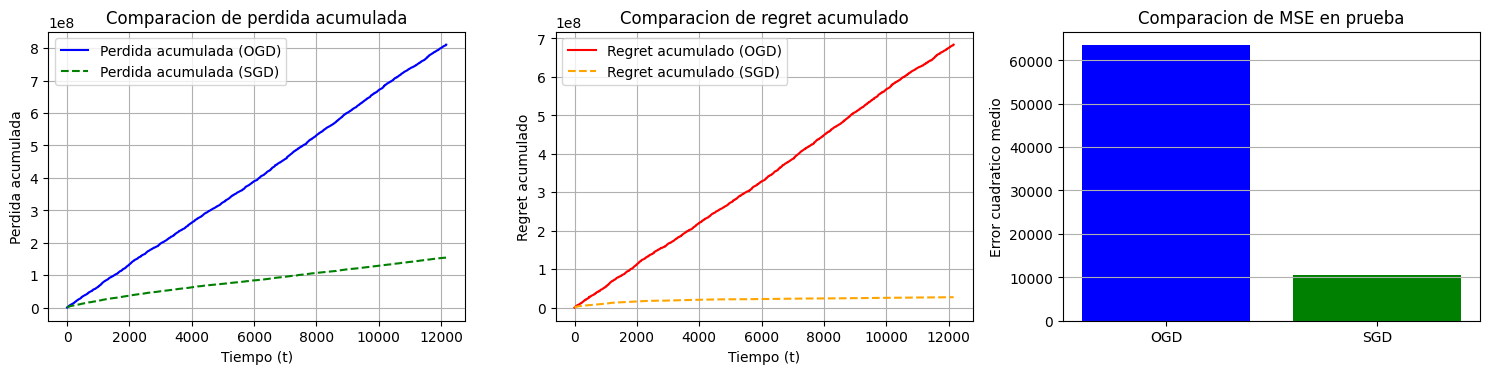

MSE en prueba con OGD: 63455.9708
MSE en prueba con SGD (scikit-learn): 10599.0729


In [19]:



fig, ejes = plt.subplots(1, 3, figsize=(15, 4))

ejes[0].plot(perdidas_acumuladas, label='Perdida acumulada (OGD)', color='blue')
ejes[0].plot(perdidas_acumuladas_sgd, label='Perdida acumulada (SGD)', color='green', linestyle='--')
ejes[0].set_xlabel('Tiempo (t)')
ejes[0].set_ylabel('Perdida acumulada')
ejes[0].set_title('Comparacion de perdida acumulada')
ejes[0].grid(True)
ejes[0].legend()

ejes[1].plot(regret_acumulado, label='Regret acumulado (OGD)', color='red')
ejes[1].plot(regret_acumulado_sgd, label='Regret acumulado (SGD)', color='orange', linestyle='--')
ejes[1].set_xlabel('Tiempo (t)')
ejes[1].set_ylabel('Regret acumulado')
ejes[1].set_title('Comparacion de regret acumulado')
ejes[1].grid(True)
ejes[1].legend()

ejes[2].bar(['OGD', 'SGD'], [mse_test_ogd, mse_test_sgd], color=['blue', 'green'])
ejes[2].set_ylabel('Error cuadratico medio')
ejes[2].set_title('Comparacion de MSE en prueba')
ejes[2].grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"MSE en prueba con OGD: {mse_test_ogd:.4f}")
print(f"MSE en prueba con SGD (scikit-learn): {mse_test_sgd:.4f}")

In [20]:
mse_test_ogd<mse_test_sgd

False

### Conclusiones

OGD vs SGD: El OGD presentó mayor MSE que SGD en prueba porque SGD realiza múltiples épocas sobre los datos, mientras que OGD aprende en una sola pasada secuencial. Esta es una consecuencia esperada del trade-off entre adaptabilidad en tiempo real y precisión.

Regret sublineal: El regret acumulado del OGD creció de forma sublineal, confirmando que el algoritmo aprende efectivamente y se acerca al mejor predictor fijo a medida que procesa más datos.

Aplicación en Bike Sharing: El dataset es ideal para aprendizaje en línea porque la demanda de bicicletas varía con la hora, el día y las estaciones. Un modelo en línea como OGD puede adaptarse a estos patrones dinámicos en tiempo real, siendo computacionalmente eficiente y adecuado para sistemas que requieren predicciones continuas.

Limitación: La precisión del OGD es inferior a la de un modelo por lotes, pero su capacidad de adaptación y eficiencia lo hacen valioso para aplicaciones de predicción en tiempo real.

## Ejercicio 13 de Agosto

### Actividades para hoy

1. Para el entorno estacionario y para el entorno no-estacionario probar con diferentes valores de $\epsilon$ y describir cómo afecta el algoritmo.

2. Para el entorno estacionario usar tasa de aprendizaje constante y describir lo observado con el desempeño del algoritmo.

3. Para el entorno no estacionario utilizar como tasa de aprendizaje $1/N(a)$ y describir lo observado con el desempeño del algoritmo.

Código original:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)

# Estimación inicial de recompensa
Q = np.zeros(n_actions)

# Número de veces que cada acción ha sido seleccionada
N = np.zeros(n_actions)

epsilon = 0.1 #<------ convertirlo en una variable y no algo fijo
T = 1000

rewards = []
actions = []

for t in range(T):

    # Exploration
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)

    # Exploitation
    else:
        action = np.argmax(Q)

    # Respuesta del usuario
    reward = np.random.rand() < true_prob[action]

    # Guardamos resultados
    rewards.append(reward)
    actions.append(action)

    # Actualizamos la estimación
    N[action] += 1
    Q[action] += (reward - Q[action]) / N[action]


for i in range(n_actions):
    print(
        content[i],
        " | valor real:", true_prob[i],
        " | valor aprendido:", round(Q[i], 3),
        " | veces mostrado:", int(N[i])
    )

Deportes  | valor real: 0.2  | valor aprendido: 0.2  | veces mostrado: 30
Noticias  | valor real: 0.6  | valor aprendido: 0.5  | veces mostrado: 30
Tecnología  | valor real: 0.8  | valor aprendido: 0.806  | veces mostrado: 907
Entretenimiento  | valor real: 0.4  | valor aprendido: 0.424  | veces mostrado: 33


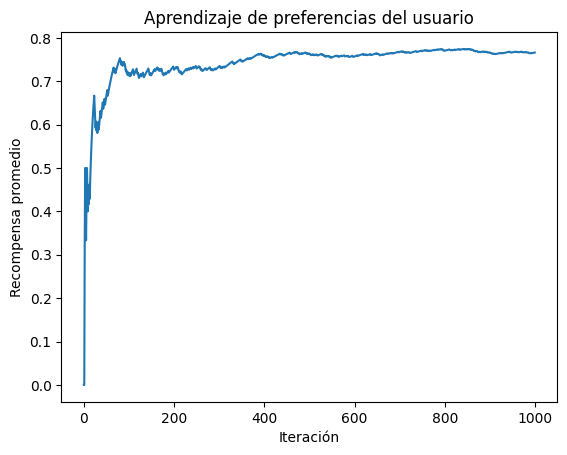

In [22]:
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)

plt.plot(average_reward)
plt.xlabel("Iteración")
plt.ylabel("Recompensa promedio")
plt.title("Aprendizaje de preferencias del usuario")
plt.show()

### Ejercicio1 

Para el entorno estacionario y para el entorno no-estacionario probar con diferentes valores de $\epsilon$ y describir cómo afecta el algoritmo.

### Entorno estacionario:

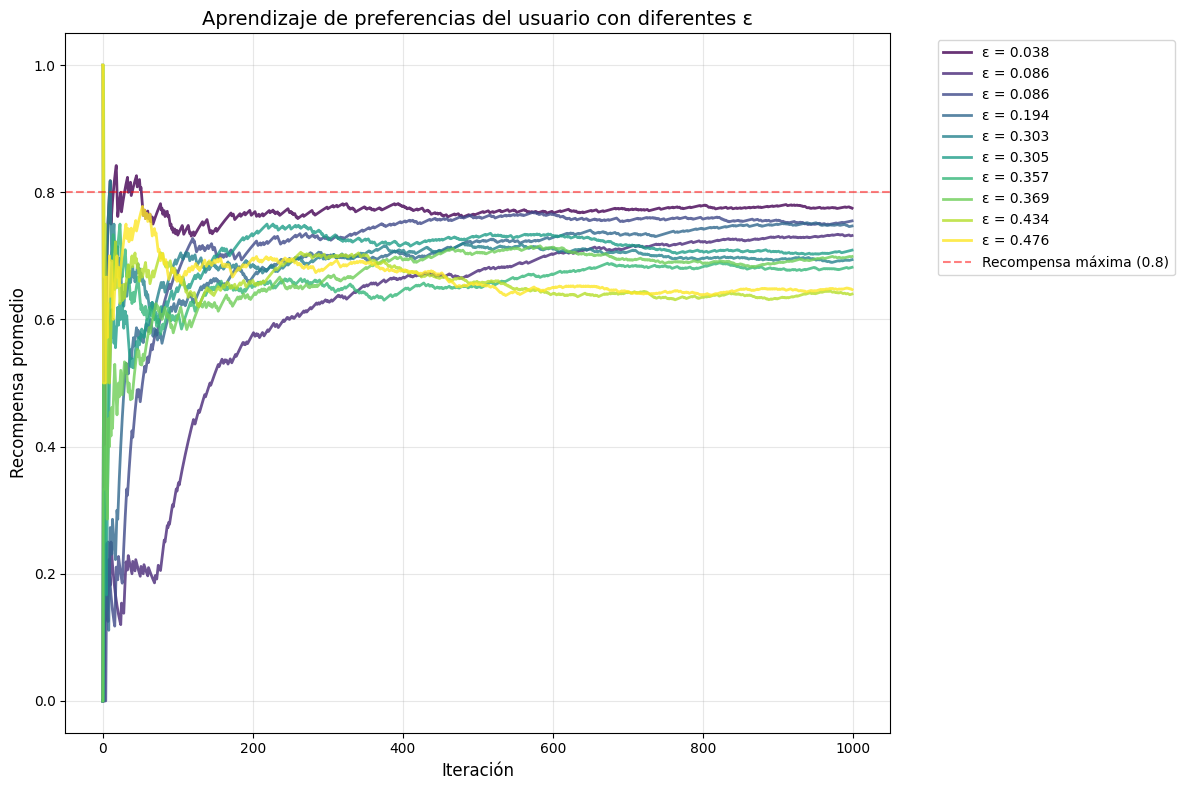


 Mejor epsilon: 0.038
   Recompensa total: 775
   Recompensa promedio final: 0.775


In [36]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]

# Preferencias reales del usuario
# El algoritmo NO conoce estos valores
true_prob = np.array([0.2, 0.6, 0.8, 0.4])

n_actions = len(content)
T = 1000

# Generar 10 valores aleatorios de epsilon
epsilon_values = np.random.uniform(0.01, 0.5, 10)
epsilon_values = np.sort(epsilon_values)  # Ordenar de menor a mayor

# Crear figura para la gráfica comparativa
plt.figure(figsize=(12, 8))

# Colores para cada epsilon
colors = plt.cm.viridis(np.linspace(0, 1, len(epsilon_values)))

# Almacenar resultados para cada epsilon
results_summary = []

for idx, epsilon in enumerate(epsilon_values):
    # Reiniciar estimaciones para cada valor de epsilon
    Q = np.zeros(n_actions)
    N = np.zeros(n_actions)
    rewards = []
    actions = []
    
    for t in range(T):
        # Exploration
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        # Exploitation
        else:
            action = np.argmax(Q)
        
        # Respuesta del usuario
        reward = np.random.rand() < true_prob[action]
        
        # Guardamos resultados
        rewards.append(reward)
        actions.append(action)
        
        # Actualizamos la estimación
        N[action] += 1
        Q[action] += (reward - Q[action]) / N[action]
    
    # Calcular recompensa promedio acumulada
    average_reward = np.cumsum(rewards) / np.arange(1, T + 1)
    
    # Graficar con color específico
    plt.plot(average_reward, 
             label=f'ε = {epsilon:.3f}', 
             color=colors[idx], 
             linewidth=2,
             alpha=0.8)
    
    # Guardar resumen
    results_summary.append({
        'epsilon': epsilon,
        'total_rewards': sum(rewards),
        'final_avg_reward': average_reward[-1],
        'Q': Q.copy(),
        'N': N.copy(),
        'actions': actions,
        'rewards': rewards
    })
    

# Configurar la gráfica
plt.xlabel("Iteración", fontsize=12)
plt.ylabel("Recompensa promedio", fontsize=12)
plt.title("Aprendizaje de preferencias del usuario con diferentes ε", fontsize=14)
plt.axhline(y=max(true_prob), color='red', linestyle='--', alpha=0.5, 
            label=f'Recompensa máxima ({max(true_prob):.1f})')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


best_epsilon = results_summary[0]['epsilon']
print(f"\n Mejor epsilon: {best_epsilon:.3f}")
print(f"   Recompensa total: {results_summary[0]['total_rewards']}")
print(f"   Recompensa promedio final: {results_summary[0]['final_avg_reward']:.3f}")

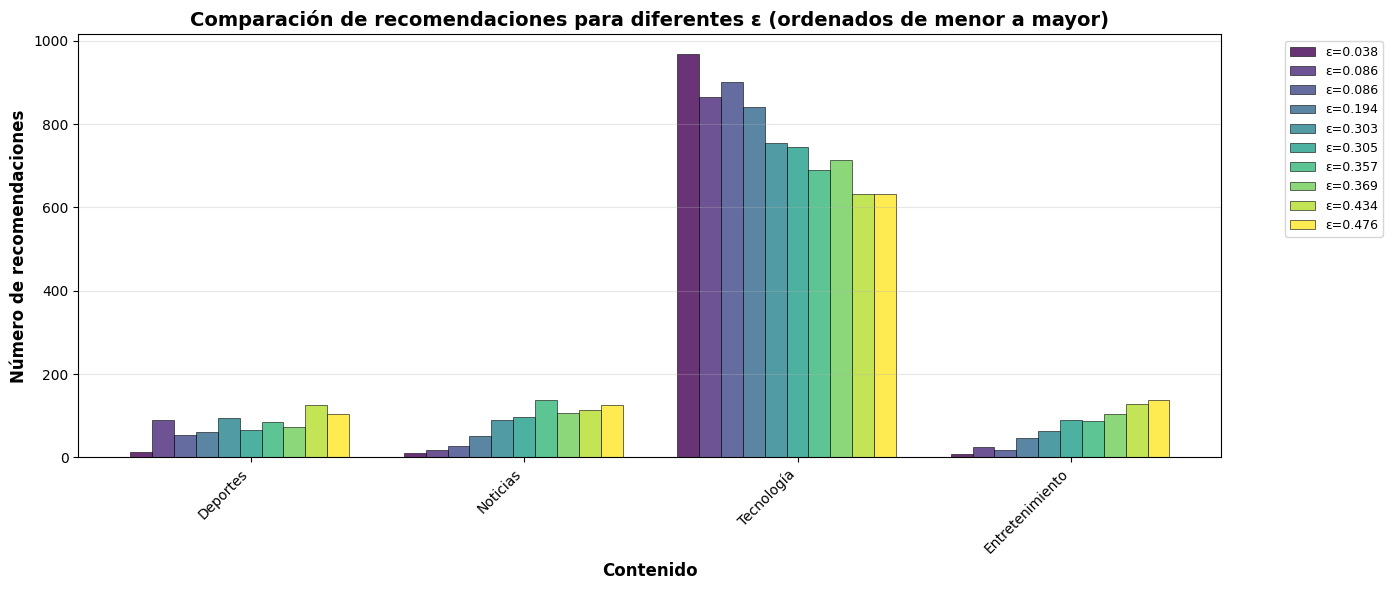

In [37]:
# Crear una gráfica resumen con barras agrupadas
fig, ax = plt.subplots(figsize=(14, 6))

# Preparar datos para gráfico agrupado
x = np.arange(n_actions)
width = 0.08
colors_epsilon = plt.cm.viridis(np.linspace(0, 1, len(epsilon_values)))

# Asegurar que epsilon_values esté ordenado de menor a mayor
epsilon_values_sorted = np.sort(epsilon_values)

# Graficar barras agrupadas para cada epsilon (ordenados de menor a mayor)
for i, epsilon in enumerate(epsilon_values_sorted):
    # Encontrar el resultado correspondiente
    result = next(r for r in results_summary if abs(r['epsilon'] - epsilon) < 1e-10)
    counts = [result['actions'].count(a) for a in range(n_actions)]
    
    # Posición de las barras para este epsilon
    offset = (i - len(epsilon_values_sorted)/2) * width
    bars = ax.bar(x + offset, counts, width, 
                  label=f'ε={epsilon:.3f}', 
                  color=colors_epsilon[i],
                  alpha=0.8,
                  edgecolor='black',
                  linewidth=0.5)

# Personalizar gráfico
ax.set_xlabel('Contenido', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de recomendaciones', fontsize=12, fontweight='bold')
ax.set_title('Comparación de recomendaciones para diferentes ε (ordenados de menor a mayor)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(content, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


Notamos que con un valor de $\epsilon$ bajo la recompensa esperada es mayor, se explota más frecuentemente la opción con mayor probabilidad de éxito. 

### No estacionario:


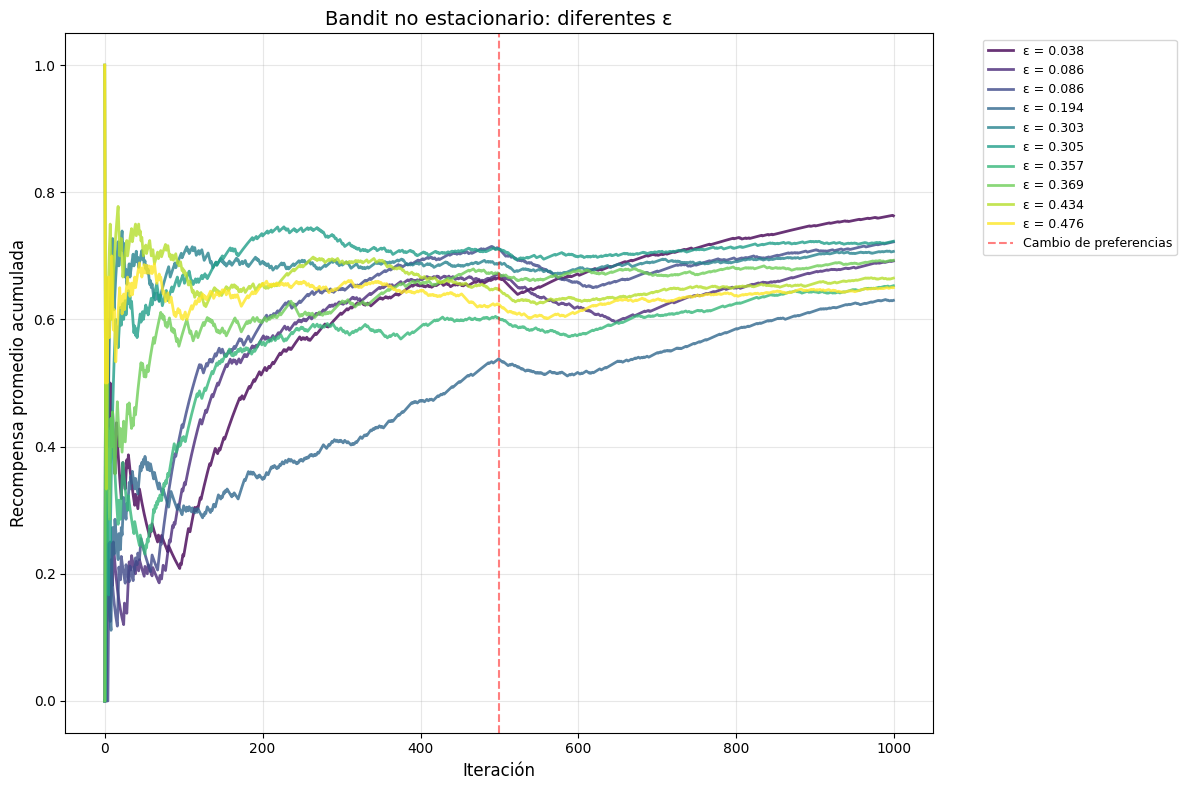

In [39]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)
alpha = 0.1
T = 1000

# Generar 10 valores aleatorios de epsilon
epsilon_values = np.random.uniform(0.01, 0.5, 10)
epsilon_values = np.sort(epsilon_values)  # Ordenar de menor a mayor

# Colores para cada epsilon
colors = plt.cm.viridis(np.linspace(0, 1, len(epsilon_values)))

# Almacenar resultados para cada epsilon
results_data = {}

# Crear figura para las curvas de aprendizaje
plt.figure(figsize=(12, 8))

for idx, epsilon in enumerate(epsilon_values):
    # Reiniciar estimaciones para cada epsilon
    Q = np.zeros(n_actions)
    N = np.zeros(n_actions)
    rewards = []
    actions = []
    best_prob_over_time = []
    
    for t in range(T):
        # Preferencias reales del usuario cambian a mitad del experimento
        if t < 500:
            true_prob = np.array([0.2, 0.5, 0.8, 0.3])
        else:
            true_prob = np.array([0.2, 0.4, 0.3, 0.9])
        
        best_prob_over_time.append(np.max(true_prob))
        
        # epsilon-greedy
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q)
        
        # Recompensa
        reward = 1 if np.random.rand() < true_prob[action] else 0
        
        actions.append(action)
        rewards.append(reward)
        N[action] += 1
        
        # Actualización para caso no estacionario
        Q[action] = Q[action] + alpha * (reward - Q[action])
    
    # Calcular recompensa promedio acumulada
    average_reward = np.cumsum(rewards) / np.arange(1, T + 1)
    
    # Graficar curva de aprendizaje
    plt.plot(average_reward, 
             label=f'ε = {epsilon:.3f}', 
             color=colors[idx], 
             linewidth=2,
             alpha=0.8)
    
    # Almacenar resultados
    results_data[epsilon] = {
        'rewards': rewards,
        'actions': actions,
        'average_reward': average_reward,
        'Q': Q.copy(),
        'N': N.copy(),
        'total_rewards': sum(rewards),
        'final_avg': average_reward[-1]
    }
    
# Configurar gráfica de aprendizaje
plt.axvline(500, linestyle="--", color='red', alpha=0.5, label='Cambio de preferencias')
plt.xlabel("Iteración", fontsize=12)
plt.ylabel("Recompensa promedio acumulada", fontsize=12)
plt.title("Bandit no estacionario: diferentes ε", fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

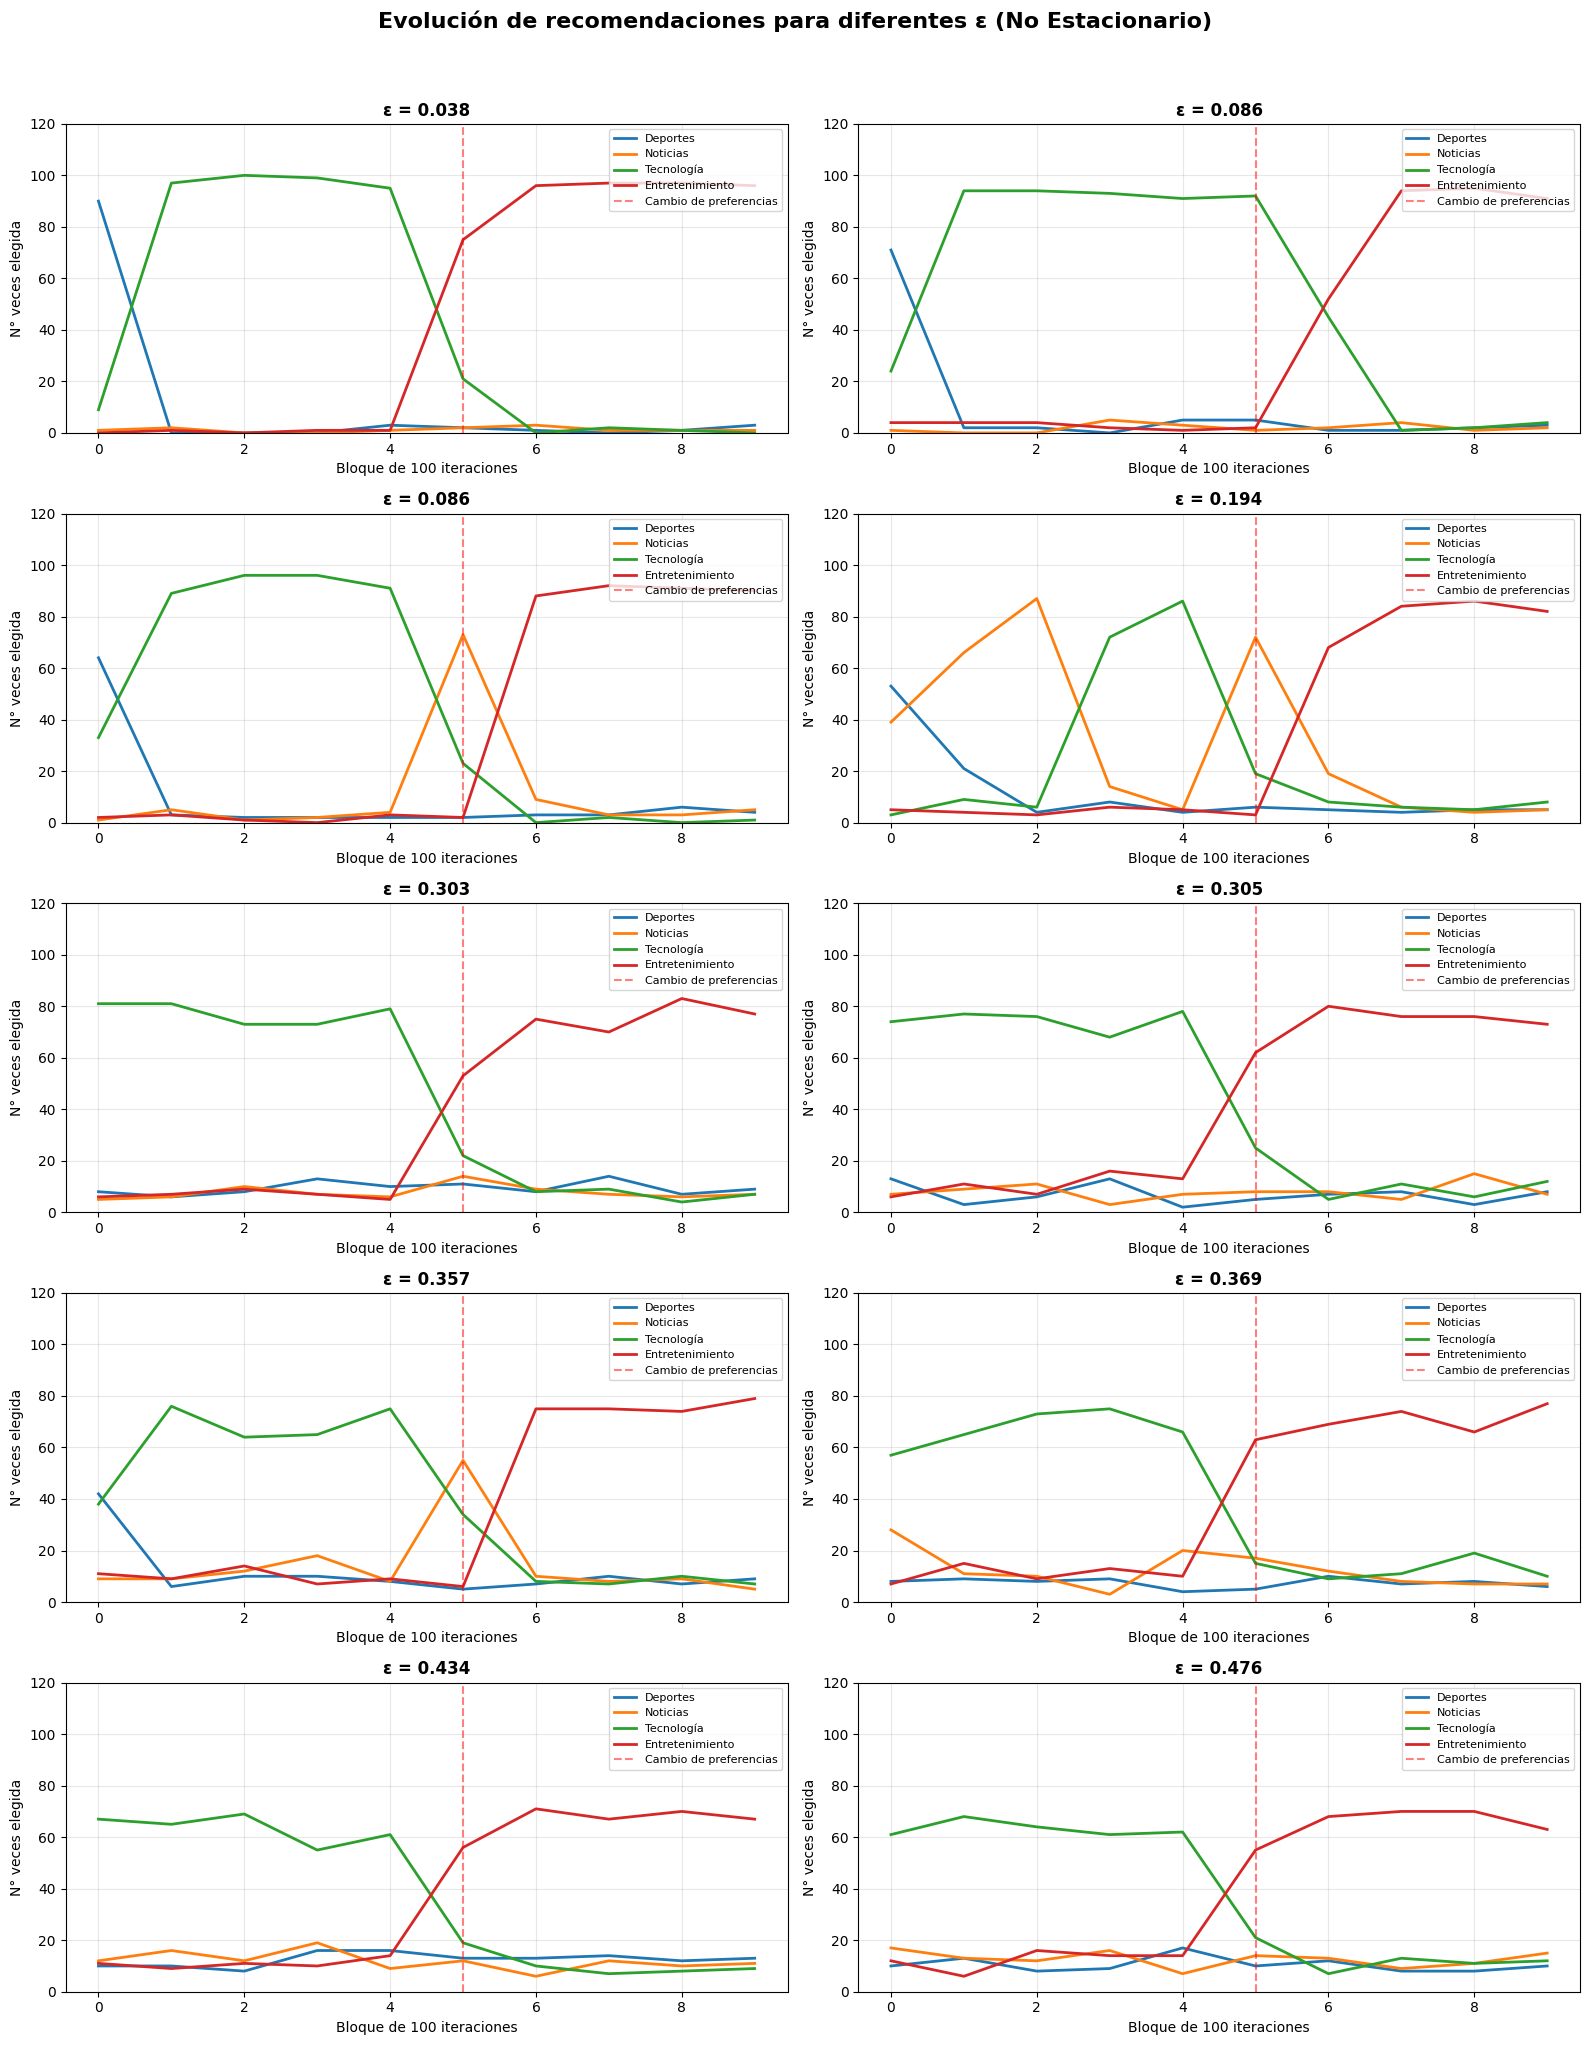

In [40]:
# Crear subplots para cada epsilon
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

window = 100

for idx, epsilon in enumerate(epsilon_values):
    actions = results_data[epsilon]['actions']
    
    # Calcular bloques de acciones elegidas
    chosen_actions = []
    for start in range(0, T, window):
        block = actions[start:start+window]
        counts = [block.count(a) for a in range(n_actions)]
        chosen_actions.append(counts)
    
    chosen_actions = np.array(chosen_actions)
    
    # Graficar en el subplot correspondiente
    ax = axes[idx]
    for a in range(n_actions):
        ax.plot(chosen_actions[:, a], label=content[a], linewidth=2)
    
    ax.axvline(5, linestyle="--", color='red', alpha=0.5, label='Cambio de preferencias')
    ax.set_xlabel("Bloque de 100 iteraciones", fontsize=10)
    ax.set_ylabel("N° veces elegida", fontsize=10)
    ax.set_title(f"ε = {epsilon:.3f}", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, window + 20)

plt.suptitle("Evolución de recomendaciones para diferentes ε (No Estacionario)", 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Conclusion ejercicio 1: 

A menor $\epsilon$ un mejor desempeño, en el no-estacionario un valor alto de epsilon implica que se recomienda en menor medida el de tecnología y que se empieza a recomendar entretenimiento antes de tiempo. Con un menor $\epsilon$ las curvas son más pronunciadas. 

Intuitivamente tenemos que una vez que el algoritmo ya aprendió qué contenido le gusta más al usuario, explorar se convierte en un desperdicio, por eso es mejor un menor epsilon.

### Ejercicio 2: 
 Para el entorno estacionario usar tasa de aprendizaje constante y describir lo observado con el desempeño del algoritmo.


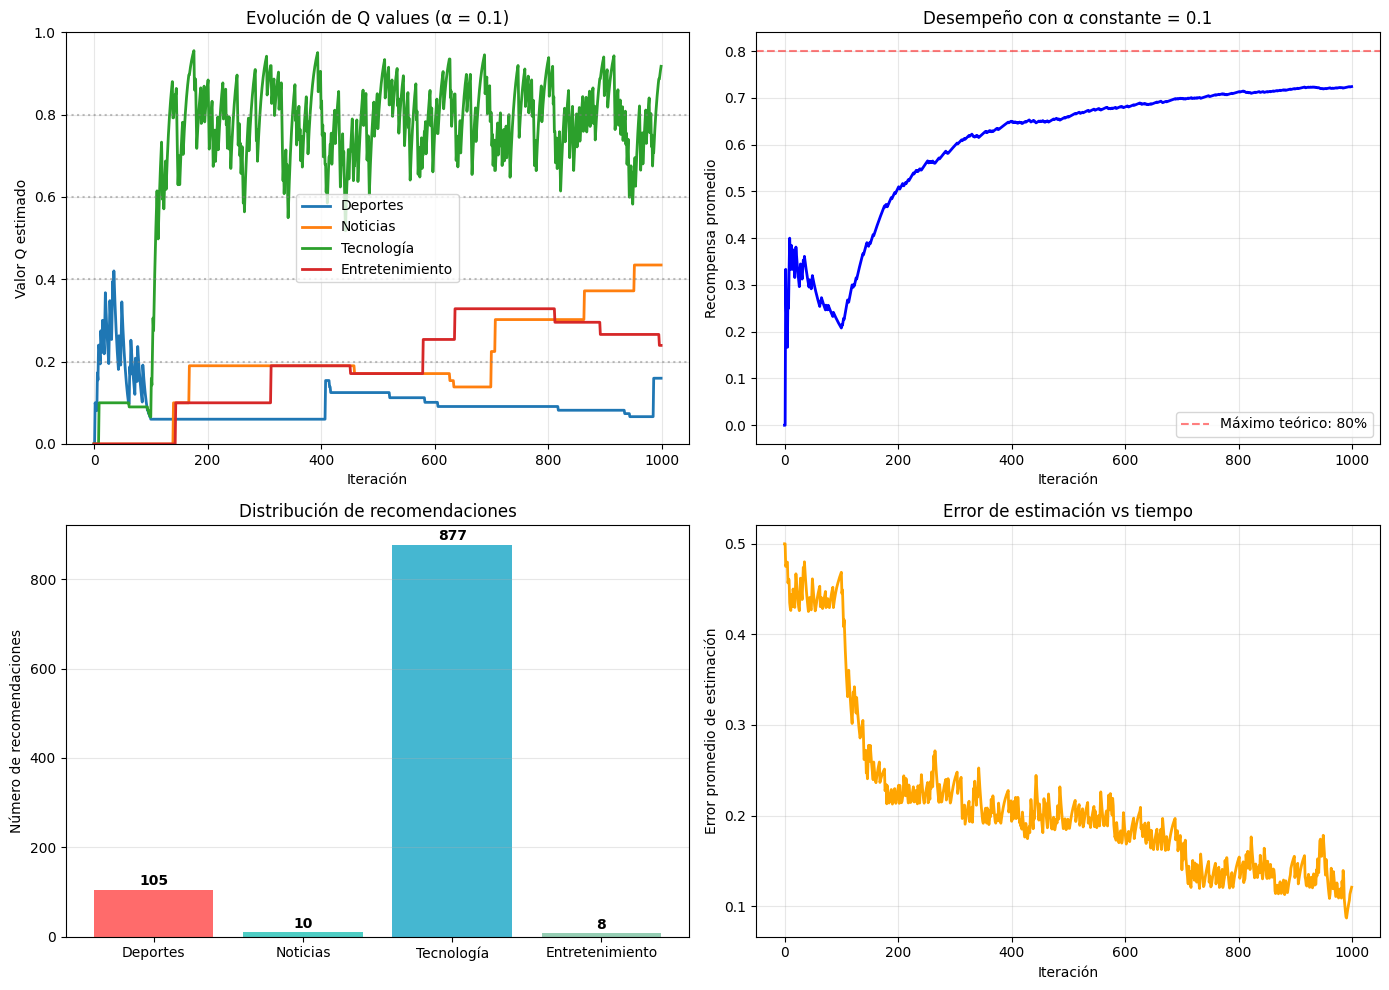

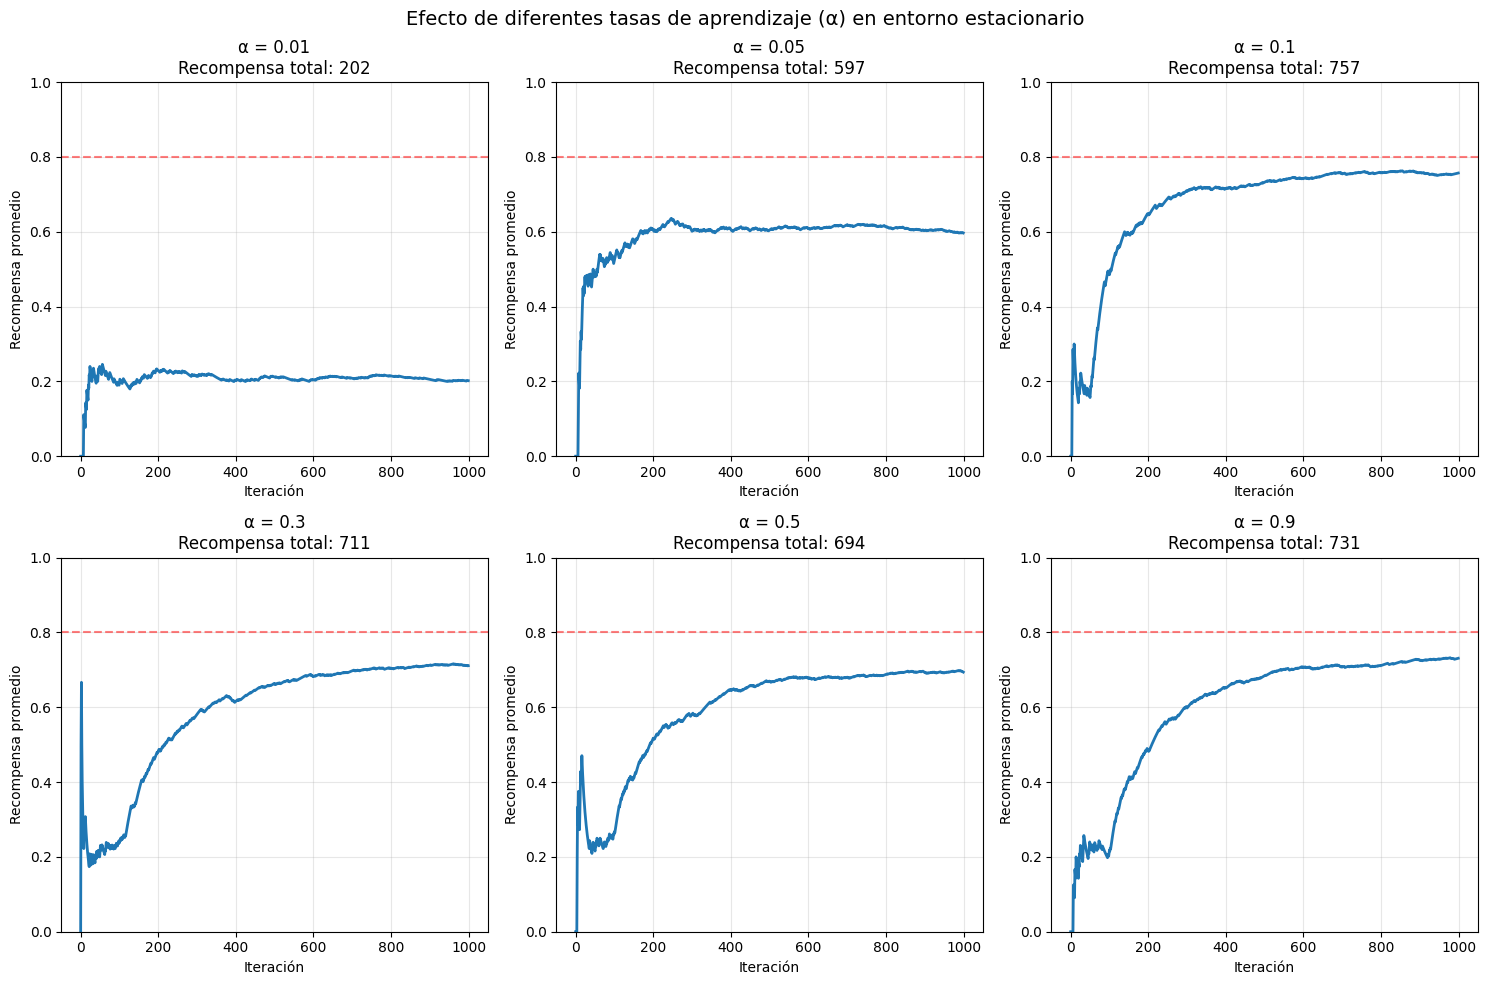

0.01       774                  0.760              0.261       
0.05       694                  0.720              0.237       
0.10       677                  0.850              0.140       
0.30       683                  0.690              0.239       
0.50       738                  0.780              0.298       
0.90       608                  0.820              0.325       


In [44]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
true_prob = np.array([0.2, 0.6, 0.8, 0.4])  # Preferencias FIJAS (estacionario)
n_actions = len(content)
T = 1000

# Parámetros
epsilon = 0.038
alpha = 0.1  # Tasa de aprendizaje constante

# Inicializar
Q = np.zeros(n_actions)
N = np.zeros(n_actions)

rewards = []
actions = []
Q_history = []

for t in range(T):
    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)
    
    # Recompensa (estacionaria)
    reward = 1 if np.random.rand() < true_prob[action] else 0
    
    rewards.append(reward)
    actions.append(action)
    N[action] += 1
    
    # Actualización con tasa de aprendizaje CONSTANTE
    Q[action] = Q[action] + alpha * (reward - Q[action])
    
    # Guardar historial
    Q_history.append(Q.copy())

Q_history = np.array(Q_history)

# Visualización 1: Evolución de Q values con alpha constante
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Evolución de Q values
ax1 = axes[0, 0]
for a in range(n_actions):
    ax1.plot(Q_history[:, a], label=content[a], linewidth=2)
for a in range(n_actions):
    ax1.axhline(y=true_prob[a], color='gray', linestyle=':', alpha=0.5)
ax1.set_xlabel("Iteración")
ax1.set_ylabel("Valor Q estimado")
ax1.set_title(f"Evolución de Q values (α = {alpha})")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Gráfico 2: Recompensa promedio acumulada
ax2 = axes[0, 1]
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)
ax2.plot(average_reward, linewidth=2, color='blue')
ax2.axhline(y=max(true_prob), color='red', linestyle='--', alpha=0.5, 
            label=f'Máximo teórico: {max(true_prob):.0%}')
ax2.set_xlabel("Iteración")
ax2.set_ylabel("Recompensa promedio")
ax2.set_title(f"Desempeño con α constante = {alpha}")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Distribución de acciones
ax3 = axes[1, 0]
counts = [actions.count(i) for i in range(n_actions)]
bars = ax3.bar(content, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax3.set_ylabel("Número de recomendaciones")
ax3.set_title("Distribución de recomendaciones")
ax3.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, count in zip(bars, counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', fontweight='bold')

# Gráfico 4: Error de estimación
ax4 = axes[1, 1]
errors = np.mean(np.abs(Q_history - true_prob), axis=1)
ax4.plot(errors, linewidth=2, color='orange')
ax4.set_xlabel("Iteración")
ax4.set_ylabel("Error promedio de estimación")
ax4.set_title("Error de estimación vs tiempo")
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



alpha_values = [0.01, 0.05, 0.1, 0.3, 0.5, 0.9]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, alpha_test in enumerate(alpha_values):
    Q = np.zeros(n_actions)
    N = np.zeros(n_actions)
    rewards_test = []
    
    for t in range(T):
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q)
        
        reward = 1 if np.random.rand() < true_prob[action] else 0
        rewards_test.append(reward)
        N[action] += 1
        Q[action] = Q[action] + alpha_test * (reward - Q[action])
    
    avg_reward = np.cumsum(rewards_test) / np.arange(1, T + 1)
    
    ax = axes[idx]
    ax.plot(avg_reward, linewidth=2)
    ax.axhline(y=max(true_prob), color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'α = {alpha_test}\nRecompensa total: {sum(rewards_test)}')
    ax.set_xlabel('Iteración')
    ax.set_ylabel('Recompensa promedio')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)

plt.suptitle('Efecto de diferentes tasas de aprendizaje (α) en entorno estacionario', fontsize=14)
plt.tight_layout()
plt.show()



for alpha_test in alpha_values:
    Q = np.zeros(n_actions)
    N = np.zeros(n_actions)
    rewards_test = []
    
    for t in range(T):
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)
        else:
            action = np.argmax(Q)
        
        reward = 1 if np.random.rand() < true_prob[action] else 0
        rewards_test.append(reward)
        N[action] += 1
        Q[action] = Q[action] + alpha_test * (reward - Q[action])
    
    error = np.mean(np.abs(Q - true_prob))
    print(f"{alpha_test:<10.2f} {sum(rewards_test):<20} {np.mean(rewards_test[-100:]):<18.3f} {error:<12.3f}")



**Conclusión**:

En un entorno estacionario con α constante:
- α pequeño (0.01-0.05): Convergencia lenta pero estable
- α moderado (0.1): Buen balance entre velocidad y estabilidad
- α grande (0.5-0.9): Rápido pero muy ruidoso, nunca converge bien

La tasa de aprendizaje constante mantiene al algoritmo "alerta" pero 
sacrifica precisión en entornos estacionarios donde no hay cambios.

### Ejercicio 3
Para el entorno no estacionario utilizar como tasa de aprendizaje $1/N(a)$ y describir lo observado con el desempeño del algoritmo.


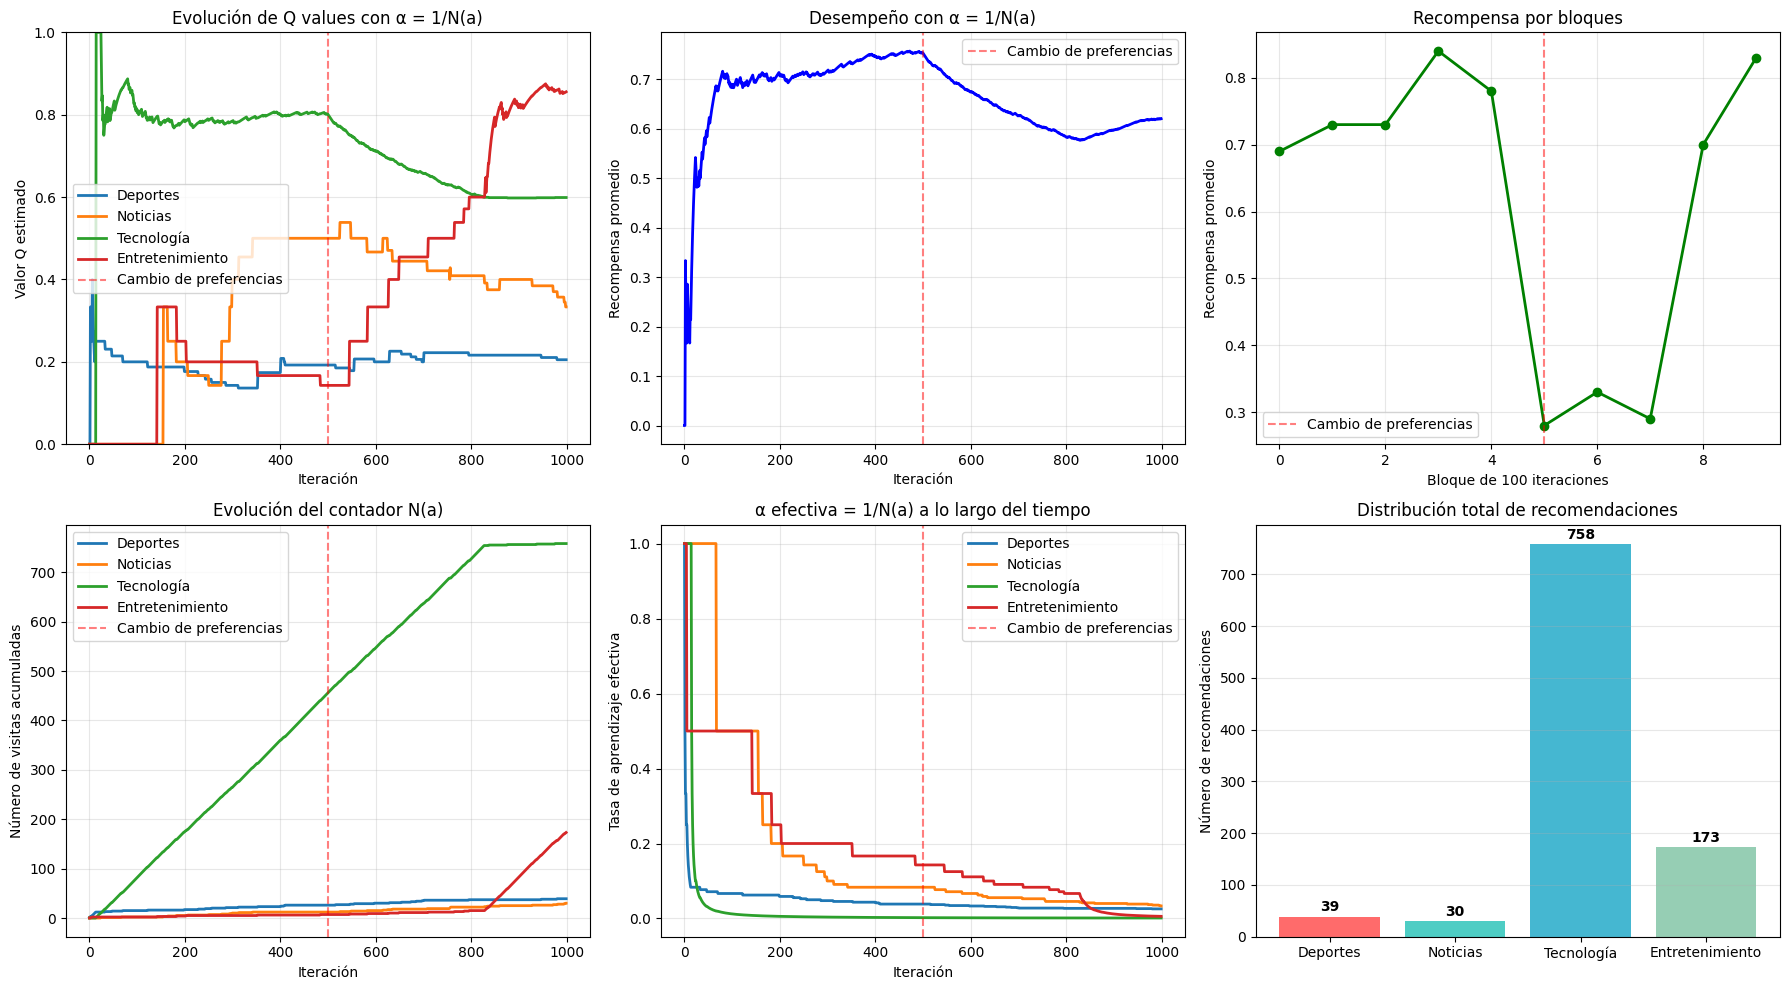

In [49]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

content = ["Deportes", "Noticias", "Tecnología", "Entretenimiento"]
n_actions = len(content)
T = 1000

# Parámetros
epsilon = 0.1

# Inicializar
Q = np.zeros(n_actions)
N = np.zeros(n_actions)  # Contador de visitas por acción

rewards = []
actions = []
Q_history = []
N_history = []

for t in range(T):
    # Preferencias reales del usuario CAMBIAN a mitad del experimento (NO estacionario)
    if t < 500:
        true_prob = np.array([0.2, 0.5, 0.8, 0.3])
    else:
        true_prob = np.array([0.2, 0.4, 0.3, 0.9])
    
    # epsilon-greedy
    if np.random.rand() < epsilon:
        action = np.random.randint(n_actions)
    else:
        action = np.argmax(Q)
    
    # Recompensa
    reward = 1 if np.random.rand() < true_prob[action] else 0
    
    rewards.append(reward)
    actions.append(action)
    N[action] += 1
    
    # Actualización con tasa de aprendizaje 1/N(a) - PROMEDIO INCREMENTAL
    Q[action] = Q[action] + (1 / N[action]) * (reward - Q[action])
    
    # Guardar historial
    Q_history.append(Q.copy())
    N_history.append(N.copy())

Q_history = np.array(Q_history)
N_history = np.array(N_history)

# Visualización completa
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Gráfico 1: Evolución de Q values
ax1 = axes[0, 0]
for a in range(n_actions):
    ax1.plot(Q_history[:, a], label=content[a], linewidth=2)
ax1.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='Cambio de preferencias')
ax1.set_xlabel("Iteración")
ax1.set_ylabel("Valor Q estimado")
ax1.set_title("Evolución de Q values con α = 1/N(a)")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# Gráfico 2: Recompensa promedio acumulada
ax2 = axes[0, 1]
average_reward = np.cumsum(rewards) / np.arange(1, T + 1)
ax2.plot(average_reward, linewidth=2, color='blue')
ax2.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='Cambio de preferencias')
ax2.set_xlabel("Iteración")
ax2.set_ylabel("Recompensa promedio")
ax2.set_title("Desempeño con α = 1/N(a)")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Gráfico 3: Recompensa promedio por bloques
ax3 = axes[0, 2]
window = 100
block_rewards = []
for start in range(0, T, window):
    block = rewards[start:start+window]
    block_rewards.append(np.mean(block))
ax3.plot(block_rewards, 'o-', linewidth=2, color='green')
ax3.axvline(x=5, color='red', linestyle='--', alpha=0.5, label='Cambio de preferencias')
ax3.set_xlabel("Bloque de 100 iteraciones")
ax3.set_ylabel("Recompensa promedio")
ax3.set_title("Recompensa por bloques")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Gráfico 4: Evolución de N(a) - contador de visitas
ax4 = axes[1, 0]
for a in range(n_actions):
    ax4.plot(N_history[:, a], label=content[a], linewidth=2)
ax4.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='Cambio de preferencias')
ax4.set_xlabel("Iteración")
ax4.set_ylabel("Número de visitas acumuladas")
ax4.set_title("Evolución del contador N(a)")
ax4.legend()
ax4.grid(True, alpha=0.3)

# Gráfico 5: Evolución de la tasa de aprendizaje efectiva
ax5 = axes[1, 1]
effective_alpha = np.zeros((T, n_actions))
for t in range(T):
    for a in range(n_actions):
        if N_history[t, a] > 0:
            effective_alpha[t, a] = 1 / N_history[t, a]
        else:
            effective_alpha[t, a] = 1.0

for a in range(n_actions):
    ax5.plot(effective_alpha[:, a], label=content[a], linewidth=2)
ax5.axvline(x=500, color='red', linestyle='--', alpha=0.5, label='Cambio de preferencias')
ax5.set_xlabel("Iteración")
ax5.set_ylabel("Tasa de aprendizaje efectiva")
ax5.set_title("α efectiva = 1/N(a) a lo largo del tiempo")
ax5.legend()
ax5.grid(True, alpha=0.3)

# Gráfico 6: Distribución de acciones
ax6 = axes[1, 2]
counts = [actions.count(i) for i in range(n_actions)]
bars = ax6.bar(content, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
ax6.set_ylabel("Número de recomendaciones")
ax6.set_title("Distribución total de recomendaciones")
ax6.grid(True, alpha=0.3, axis='y')

# Añadir valores en las barras
for bar, count in zip(bars, counts):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, 
             str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()






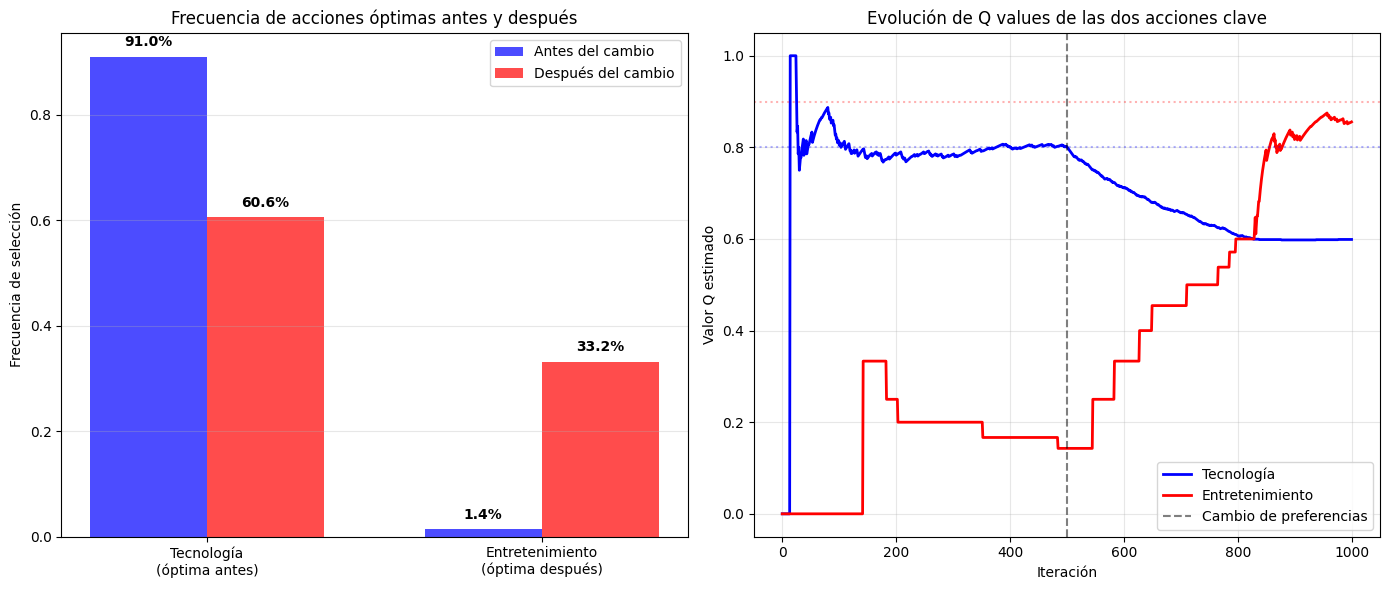

In [48]:

# Calcular métricas antes y después del cambio
rewards_before = rewards[:500]
rewards_after = rewards[500:]

optimal_before = 2  # Tecnología
optimal_after = 3   # Entretenimiento

actions_before = actions[:500]
actions_after = actions[500:]



# Visualización de la adaptación
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Frecuencia de acciones óptimas antes y después
ax1 = axes[0]
x = np.arange(2)
width = 0.35

freq_before = [actions_before.count(optimal_before)/500, 
               actions_before.count(optimal_after)/500]
freq_after = [actions_after.count(optimal_before)/500, 
              actions_after.count(optimal_after)/500]

bars1 = ax1.bar(x - width/2, freq_before, width, label='Antes del cambio', color='blue', alpha=0.7)
bars2 = ax1.bar(x + width/2, freq_after, width, label='Después del cambio', color='red', alpha=0.7)

ax1.set_ylabel('Frecuencia de selección')
ax1.set_title('Frecuencia de acciones óptimas antes y después')
ax1.set_xticks(x)
ax1.set_xticklabels(['Tecnología\n(óptima antes)', 'Entretenimiento\n(óptima después)'])
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Añadir valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.02, 
                 f'{height:.1%}', ha='center', fontweight='bold')

# Gráfico 2: Evolución temporal de Q values clave
ax2 = axes[1]
ax2.plot(Q_history[:, 2], label='Tecnología', linewidth=2, color='blue')
ax2.plot(Q_history[:, 3], label='Entretenimiento', linewidth=2, color='red')
ax2.axvline(x=500, color='black', linestyle='--', alpha=0.5, label='Cambio de preferencias')
ax2.axhline(y=0.8, color='blue', linestyle=':', alpha=0.3)
ax2.axhline(y=0.9, color='red', linestyle=':', alpha=0.3)
ax2.set_xlabel('Iteración')
ax2.set_ylabel('Valor Q estimado')
ax2.set_title('Evolución de Q values de las dos acciones clave')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()




Conclusión:

En un entorno no estacionario, usar $\alpha = 1/N(a)$ no es lo ideal porque:

1. **Inercia al cambio**: 
   Las acciones visitadas frecuentemente antes del cambio tienen 
   tasas de aprendizaje muy pequeñas, lo que dificulta actualizar 
   su valor cuando las preferencias cambian.

2. **Lenta adaptación**: 
   El algoritmo tarda mucho en reconocer que "Entretenimiento" 
   es ahora la mejor opción porque sigue "pegado" a "Tecnología".

3. **Desempeño suboptimo**: 
   Durante el período de adaptación, el algoritmo sigue recomendando 
   la opción incorrecta, perdiendo recompensas potenciales.

4. **Contraste con $\alpha $ constante**:
   Con α constante (como 0.1), el algoritmo se adapta mucho más 
   rápido porque todas las observaciones tienen el mismo peso, 
   permitiendo "desaprender" rápidamente lo que ya no es cierto.

RECOMENDACIÓN:
Para entornos no estacionarios, es mejor usar una tasa de aprendizaje 
constante (α) que permita una adaptación rápida a los cambios.
